In [3]:
import pandas as pd

df = pd.read_csv(
"/kaggle/input/notebooks/miljan/customer-segmentation/final_dataset_V2.csv"
)

df.head()

,CustomerID,min,max,mean,min_recency,max_recency,frequency,monetary_value,quantity,country,...,Cluster_125,Cluster_126,Cluster_127,Cluster_128,Cluster_129,Cluster_130,Cluster_131,Cluster_132,Cluster_133,Cluster_134
0,12346,0.0,0.0,0.000000,325.0,325.0,1,0.00,74215,35,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000
1,12347,13.2,45.0,23.308571,2.0,367.0,7,4310.00,2458,16,...,0.018376,0.0,0.0,0.00181,0.0,0.0,0.000000,0.002506,0.0,0.00348
2,12348,39.6,150.0,82.840000,75.0,358.0,4,1437.24,2332,12,...,0.277365,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000
3,12349,15.0,15.0,15.000000,18.0,18.0,1,1457.55,630,18,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.017495,0.000000,0.0,0.00000
4,12350,25.2,25.2,25.200000,310.0,310.0,1,294.40,196,24,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4335 entries, 0 to 4334
Columns: 146 entries, CustomerID to Cluster_134
dtypes: float64(141), int64(5)
memory usage: 4.8 MB


In [5]:
df.columns


Index(['CustomerID', 'min', 'max', 'mean', 'min_recency', 'max_recency',
       'frequency', 'monetary_value', 'quantity', 'country',
       ...
       'Cluster_125', 'Cluster_126', 'Cluster_127', 'Cluster_128',
       'Cluster_129', 'Cluster_130', 'Cluster_131', 'Cluster_132',
       'Cluster_133', 'Cluster_134'],
      dtype='object', length=146)

In [6]:
df.describe

<bound method NDFrame.describe of       CustomerID    min     max       mean  min_recency  max_recency  \
0          12346   0.00    0.00   0.000000        325.0        325.0   
1          12347  13.20   45.00  23.308571          2.0        367.0   
2          12348  39.60  150.00  82.840000         75.0        358.0   
3          12349  15.00   15.00  15.000000         18.0         18.0   
4          12350  25.20   25.20  25.200000        310.0        310.0   
...          ...    ...     ...        ...          ...          ...   
4330       18280  23.70   23.70  23.700000        277.0        277.0   
4331       18281   5.04    5.04   5.040000        180.0        180.0   
4332       18282  12.75   25.50  19.125000          7.0        126.0   
4333       18283   0.85   17.70   4.171875          3.0        337.0   
4334       18287  10.20   45.00  26.800000         42.0        201.0   

      frequency  monetary_value  quantity  country  ...  Cluster_125  \
0             1            0.

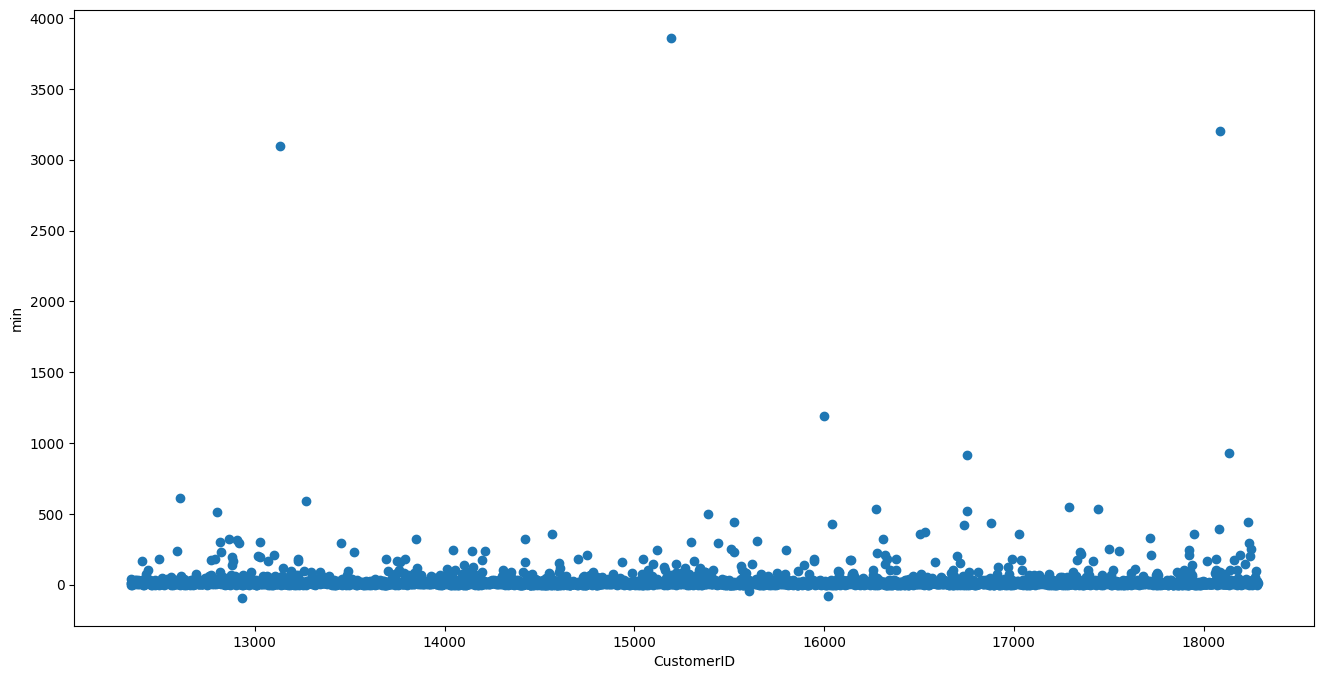

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.scatter(df.iloc[:,0],df.iloc[:,1])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [14]:
x = df.select_dtypes(include=['int64','float64'])
x.head()

,CustomerID,min,max,mean,min_recency,max_recency,frequency,monetary_value,quantity,country,...,Cluster_125,Cluster_126,Cluster_127,Cluster_128,Cluster_129,Cluster_130,Cluster_131,Cluster_132,Cluster_133,Cluster_134
0,12346,0.0,0.0,0.000000,325.0,325.0,1,0.00,74215,35,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000
1,12347,13.2,45.0,23.308571,2.0,367.0,7,4310.00,2458,16,...,0.018376,0.0,0.0,0.00181,0.0,0.0,0.000000,0.002506,0.0,0.00348
2,12348,39.6,150.0,82.840000,75.0,358.0,4,1437.24,2332,12,...,0.277365,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000
3,12349,15.0,15.0,15.000000,18.0,18.0,1,1457.55,630,18,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.017495,0.000000,0.0,0.00000
4,12350,25.2,25.2,25.200000,310.0,310.0,1,294.40,196,24,...,0.000000,0.0,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.00000


In [15]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters = 5, random_state = 42)
labels = km.fit_predict(x)

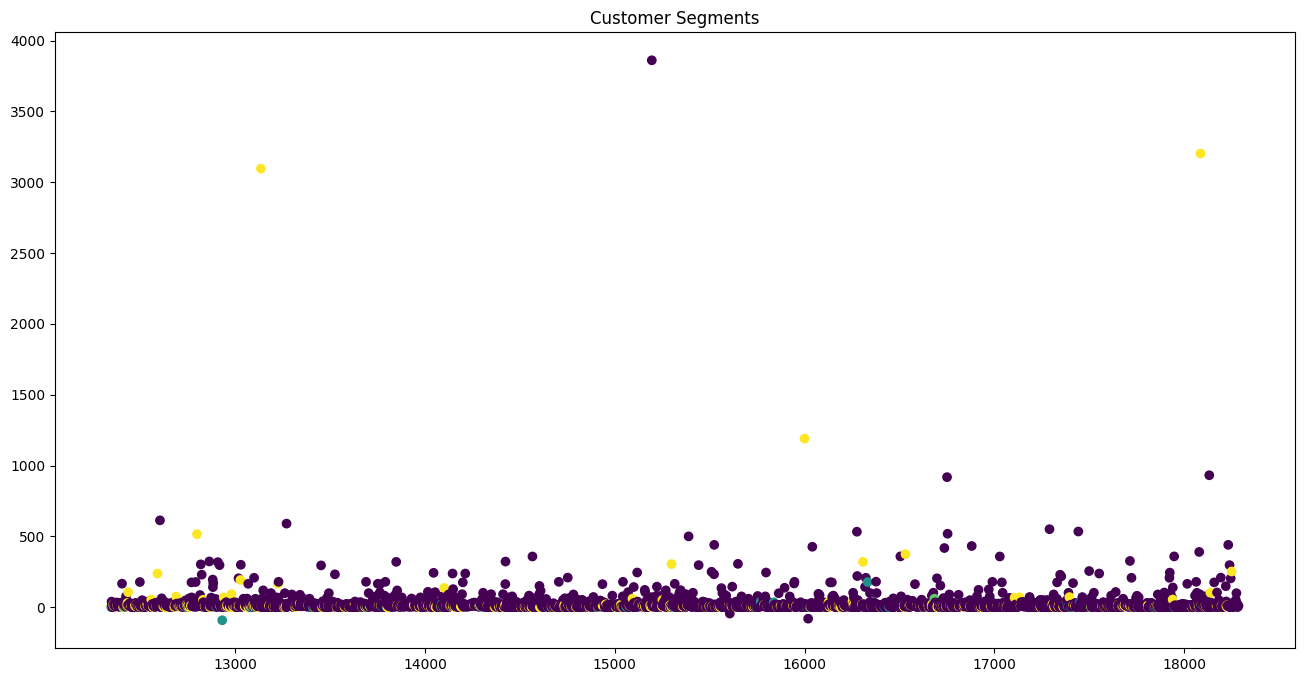

In [16]:
plt.figure(figsize=(16,8))
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=labels)
plt.title("Customer Segments")
plt.show()

In [17]:
df['cluster'] = labels

In [18]:
df.groupby("cluster").mean()

,CustomerID,min,max,mean,min_recency,max_recency,frequency,monetary_value,quantity,country,...,Cluster_125,Cluster_126,Cluster_127,Cluster_128,Cluster_129,Cluster_130,Cluster_131,Cluster_132,Cluster_133,Cluster_134
cluster,,,,,,,,,,,,,,,,,,,,,
0,15327.309902,21.659937,49.074331,32.751364,98.407911,213.566893,3.002016,903.520431,550.460317,33.293273,...,0.014725,0.001001,0.001272,0.004225,0.003217,0.000929,0.005111,0.002207,0.004025,0.000610
1,16732.666667,13.120000,3812.360000,513.055091,3.000000,362.666667,59.666667,243938.983333,110505.666667,31.000000,...,0.007846,0.000161,0.000000,0.000430,0.001042,0.000000,0.005195,0.000503,0.010406,0.000080
2,15072.482759,8.355172,865.516897,262.373563,24.758621,341.206897,41.482759,34068.285862,27587.724138,34.862069,...,0.015488,0.000285,0.000216,0.001596,0.000833,0.000070,0.003576,0.000296,0.002344,0.000608
3,15057.142857,9.085714,917.791429,179.296523,11.571429,365.428571,63.285714,93723.741429,62007.285714,22.857143,...,0.018586,0.000258,0.000088,0.007538,0.005376,0.000000,0.008036,0.002285,0.003284,0.000773
4,14964.587156,40.427401,211.881713,91.677711,25.489297,319.844037,14.266055,7143.118593,4297.467890,32.039755,...,0.020296,0.000449,0.000324,0.004257,0.003081,0.000303,0.003541,0.001440,0.004497,0.000349


In [19]:
df.columns


Index(['CustomerID', 'min', 'max', 'mean', 'min_recency', 'max_recency',
       'frequency', 'monetary_value', 'quantity', 'country',
       ...
       'Cluster_125', 'Cluster_126', 'Cluster_127', 'Cluster_128',
       'Cluster_129', 'Cluster_130', 'Cluster_131', 'Cluster_132',
       'Cluster_133', 'Cluster_134'],
      dtype='object', length=146)

In [20]:
features = [
"min_recency",
"max_recency",
"frequency",
"monetary_value",
"quantity"
]
X = df[features]

In [21]:
X.head()

,min_recency,max_recency,frequency,monetary_value,quantity
0,325.0,325.0,1,0.00,74215
1,2.0,367.0,7,4310.00,2458
2,75.0,358.0,4,1437.24,2332
3,18.0,18.0,1,1457.55,630
4,310.0,310.0,1,294.40,196


In [22]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_sc = Scaler.fit_transform(X)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_sc)

In [25]:
df["cluster"] = labels

In [32]:
df.groupby("cluster")[features].mean()

,min_recency,max_recency,frequency,monetary_value,quantity
cluster,,,,,
0,249.139313,283.072519,1.644084,490.917834,285.556298
1,49.300901,92.705105,2.003604,698.862991,456.960360
2,34.858200,317.363132,8.228113,4081.163397,2525.005549


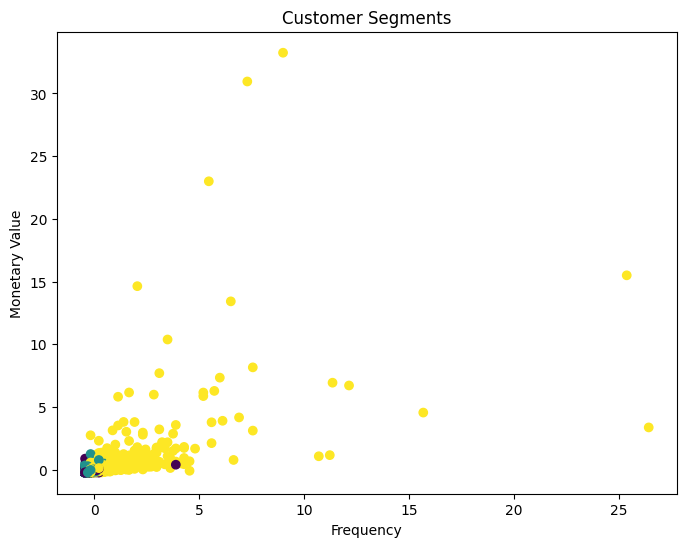

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
X_sc[:,2],
X_sc[:,3],
c=labels
)

plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segments")

plt.show()

In [33]:
kmeans.cluster_centers_

array([[ 1.56804391,  0.511425  , -0.3407695 , -0.17099959, -0.17903664],
       [-0.42839285, -1.10646765, -0.29403254, -0.14602778, -0.1451517 ],
       [-0.5717157 ,  0.8004799 ,  0.51946755,  0.25912029,  0.26339787]])

In [35]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    kmeans.fit(X_sc)
    inertia.append(kmeans.inertia_)

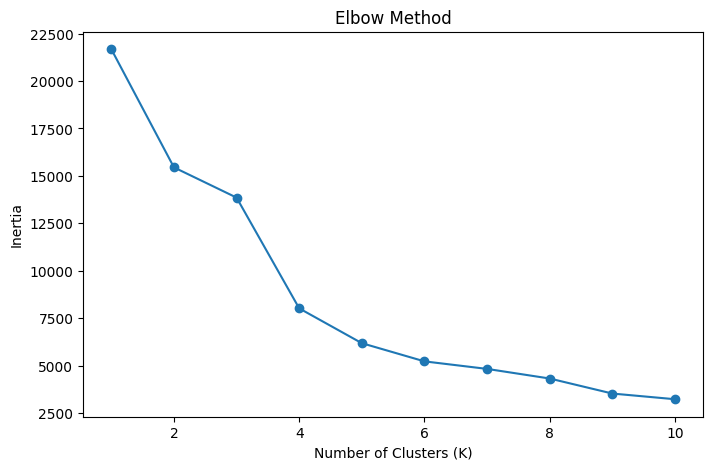

In [37]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_sc)

df["cluster"] = labels

In [41]:
df.groupby("cluster")[features].mean()

,min_recency,max_recency,frequency,monetary_value,quantity
cluster,,,,,
0,251.547665,282.774319,1.617704,503.982004,293.488327
1,49.689677,88.358209,1.949005,680.833856,448.421642
2,36.241503,313.134168,7.271914,2878.930704,1723.337507
3,20.681818,358.136364,64.227273,84404.303182,56493.454545


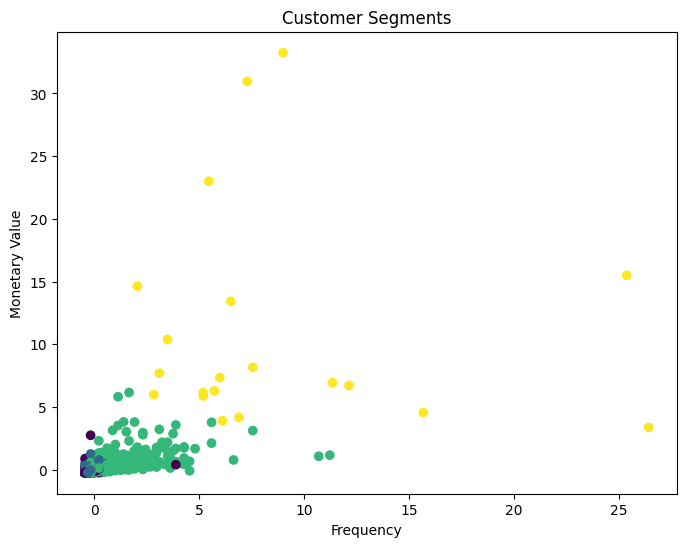

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
X_sc[:,2],   # frequency
X_sc[:,3],   # monetary_value
c=labels
)

plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segments")

plt.show()

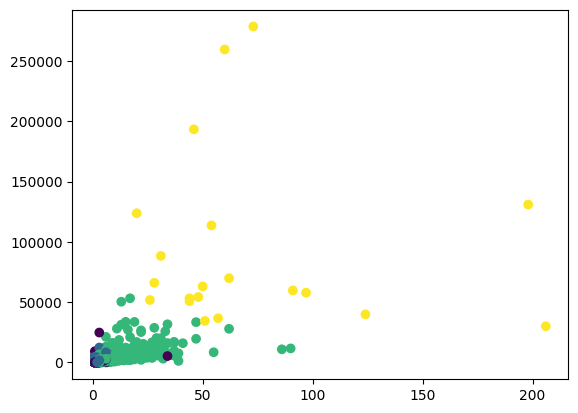

In [44]:
plt.scatter(
df["frequency"],
df["monetary_value"],
c=df["cluster"]
)

In [45]:
df["cluster"].value_counts()

cluster
2    1677
1    1608
0    1028
3      22
Name: count, dtype: int64

In [46]:
import joblib
joblib.dump(kmeans, "/kaggle/working/kmeans_customer_model.pkl")

['/kaggle/working/kmeans_customer_model.pkl']

In [47]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_sc,labels)
print("Performnance of clusters: ",score)

Performnance of clusters:  0.49627413772815376
